# Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from __future__ import division
import os
import sys
from sklearn.metrics import precision_score, recall_score
import glob
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt
import sys
'''importing the libraries'''

from tensorflow.keras.models import Sequential
import os
from keras.layers import LeakyReLU
import cv2
import numpy as np
import matplotlib.pyplot as plt
# from keras.wrappers.scikit_learn import KerasClassifier
%matplotlib inline
from tqdm.notebook import tqdm, trange
# Importing libraries
from keras.layers import Dropout, BatchNormalization
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve,roc_auc_score
import pandas as pd
#from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import imblearn
import numpy as np
from sklearn.svm import LinearSVC
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, CategoricalNB, BernoulliNB
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn import linear_model
from tqdm.notebook import tqdm, trange
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
from sklearn.feature_selection import chi2
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, CategoricalNB, BernoulliNB
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn import linear_model
from tqdm import tqdm, trange
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
import warnings
import math
import statsmodels
import numpy as np
from scipy import stats
import statsmodels.api as smf
import numpy as np
import pandas as pd
import arviz
import seaborn as sns
from sklearn.linear_model import LinearRegression

%matplotlib inline
%precision 4
plt.style.use('ggplot')
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, CategoricalNB, BernoulliNB
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import Lasso
from sklearn import linear_model
from tqdm.notebook import tqdm, trange
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE
import patsy
# from theano import shared

Mounted at /content/drive


# Functions

In [ ]:
def firth_likelihood(beta, logit):
    return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))

# Do firth regression
# Note information = -hessian, for some reason available but not implemented in statsmodels
def fit_firth(y, X, start_vec=None, step_limit=1000000, convergence_limit=0.00001):

    logit_model = smf.Logit(y, X)

    if start_vec is None:
        start_vec = np.zeros(X.shape[1])

    beta_iterations = []
    beta_iterations.append(start_vec)
    for i in range(0, step_limit):
        pi = logit_model.predict(beta_iterations[i])
        W = np.diagflat(np.multiply(pi, 1-pi))
        var_covar_mat = np.linalg.pinv(-logit_model.hessian(beta_iterations[i]))

        # build hat matrix
        rootW = np.sqrt(W)
        H = np.dot(np.transpose(X), np.transpose(rootW))
        H = np.matmul(var_covar_mat, H)
        H = np.matmul(np.dot(rootW, X), H)

        # penalised score
        U = np.matmul(np.transpose(X), y - pi + np.multiply(np.diagonal(H), 0.5 - pi))
        new_beta = beta_iterations[i] + np.matmul(var_covar_mat, U)

        # step halving
        j = 0
        while firth_likelihood(new_beta, logit_model) > firth_likelihood(beta_iterations[i], logit_model):
            new_beta = beta_iterations[i] + 0.5*(new_beta - beta_iterations[i])
            j = j + 1
            if (j > step_limit):
                sys.stderr.write('Firth regression failed\n')
                return None

        beta_iterations.append(new_beta)
        if i > 0 and (np.linalg.norm(beta_iterations[i] - beta_iterations[i-1]) < convergence_limit):
            break

    return_fit = None
    if np.linalg.norm(beta_iterations[i] - beta_iterations[i-1]) >= convergence_limit:
        sys.stderr.write('Firth regression failed\n')
    else:
        # Calculate stats
        fitll = -firth_likelihood(beta_iterations[-1], logit_model)
        intercept = beta_iterations[-1][0]
        beta = beta_iterations[-1][1:].tolist()
        bse = np.sqrt(np.diagonal(np.linalg.pinv(-logit_model.hessian(beta_iterations[-1]))))

        return_fit = intercept, beta, bse, fitll

    return return_fit

def get_predictions(X,weights):
    z = np.dot(X,weights)
    y_pred =  1/(1 + np.exp(-z))
    return y_pred

def act_minmax_scale(df, feat_to_scale, maxes,mins):

    scaled_col_dict = {}

    for col in feat_to_scale:
        x = df[col]
        max_ = maxes[col]
        min_ = mins[col]
        scaled_col = (x - min_)/(max_ - min_)
        scaled_col_dict[col] = scaled_col

    scaled_feats = pd.DataFrame(scaled_col_dict)
    return scaled_feats

def data_split(df,split_ratio = 0.20):
  df0 = df.copy()
#df
  df0 = df0.sample(frac = 1)

  data_X = df0.iloc[:,0:len(df0.columns)-1] # stores the dataset except the last column because it the target variable
  data_Y =  df0.iloc[:,len(df0.columns)-1] # target variable only

  X_train, X_test, Y_train, Y_test = train_test_split(data_X, data_Y,test_size = split_ratio ,random_state=45,stratify=data_Y)
  return X_train, X_test, Y_train, Y_test, data_X, data_Y

def intercept_df(df):
  #d = df
  df_i = df.copy()
  df_i.insert(loc=0, column='intercept', value=np.ones(df.shape[0],dtype = 'int'), allow_duplicates=True)
  return df_i

def over_sample_(df):
  df0 = df.copy()
  df0 = df0.sample(frac = 1)

  data_X = df0.iloc[:-500,0:len(df0.columns)-1] # stores the dataset except the last column because it the target variable
  data_Y =  df0.iloc[:-500,len(df0.columns)-1] # target variable only

  data_Vx =  df0.iloc[500:, 0: len(df0.columns)-1]
  data_Vy = df0.iloc[500:,len(df0.columns)-1]

  oversample = SMOTE()
  X, y = oversample.fit_resample(data_X, data_Y)

  X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size = 0.20 ,random_state=42)
  return  X_train, X_test, Y_train, Y_test,data_Vx,data_Vy


def pre_process(df, type_ = 'train', problem_type = 'preop'):
  df0 = df.copy()

  if problem_type == 'preop':
    # BPsystolic: Data Type Change and Imputation
    df0['BPsystolic'] = pd.to_numeric(df0['BPsystolic'],errors = 'coerce')
    m1 = df0.loc[df0['hypertension'] == 1, 'BPsystolic'].mean()
    m2 = df0.loc[df0['hypertension'] == 0, 'BPsystolic'].mean()
    df0.loc[df0['hypertension'] == 1, 'BPsystolic'] = df0.loc[df0['hypertension'] == 1, 'BPsystolic'].fillna(m1)
    df0.loc[df0['hypertension'] == 0, 'BPsystolic'] = df0.loc[df0['hypertension'] == 0, 'BPsystolic'].fillna(m2)

    # diastolic: Data Type Change and Imputation
    # df0['diastolic'] = pd.to_numeric(df0['diastolic'],errors = 'coerce')
    # m3 = df0.loc[df0['hypertension'] == 1, 'diastolic'].mean()
    # m4 = df0.loc[df0['hypertension'] == 0, 'diastolic'].mean()
    # df0.loc[df0['hypertension'] == 1, 'diastolic'] = df0.loc[df0['hypertension'] == 1, 'diastolic'].fillna(m3)
    # df0.loc[df0['hypertension'] == 0, 'diastolic'] = df0.loc[df0['hypertension'] == 0, 'diastolic'].fillna(m4)

    # ejection_fraction: Data Type Change
    df0['ejection_fraction'] = pd.to_numeric(df0['ejection_fraction'],errors = 'coerce')

    # Last Hematocrit: Data Type Change
    df0['last_hematocrit']= pd.to_numeric(df0['last_hematocrit'],errors = 'coerce')

    if type_ == 'test':
      # gender_id: Starting Index from 0
      df0['gender_id'] = df0['gender_id'].apply(lambda x: x-1)
      # Cardiac_Presentation_on_Admission: Starting Index from 0
      df0['Cardiac_Presentation_on_Admission'] = df0['Cardiac_Presentation_on_Admission'].apply(lambda x: x-1)

    #FirstCVSurgery: Starting Index from 0
    df0['FirstCVSurgery'] = df0['FirstCVSurgery'].apply(lambda x: x-1)

    #CABG_status: Index Starting from 0
    df0['CABG_status'] = df0['CABG_status'].apply(lambda x: x-1)

    # Dropping NAs
    df0 = df0.dropna()

    # categorical Conversion
    cat_list = ['gender_id',
                'Active_tobacco_use',
                'f_history_cad',
                'diabetes',
                'Dyslipidemia',
                'dialysis',
                'hypertension',
                'Cerebovascular_disease',
                'Carotid_disease',
                'chronic_lung_disease',
                'FirstCVSurgery',
                'previous_coronary_bypass',
                'previous_valve',
                'intracardiac_device',
                'Prior_PCI',
                'PCI_timing',
                'myocardial_infarction',
                'MI_timing',
                'congestive_heart_failure_A',
                'previous_cv_interventions',
                'NYHA_class',
                'Cardiac_Presentation_on_Admission',
                'Angina_class',
                'cardiogenic_shock',
                'resuscitation',
                'arrhythmia',
                'SustVTVF',
                'AFibFlutter',
                'ventilator_used',
                'beta_blockers_A',
                'ace_inhibitors_A',
                'nitratesIV',
                'anti_coagulants',
                'warfarin_A',
                'inotropes',
                'steroids',
                'aspirin_A',
                'lipid_lowering_A',
                'Statin_A',
                'adp_inhibitors_within_5days',
                'bronchodilators',
                'Coronaries_diseased',
                'left_main_disease',
                'pulmonary_artery_hypertension',
                'Aortic_regurgitation',
                'Mitral_regurgitation',
                'Tricuspid_regurgitation',
                'CABG_status']

    for cat in cat_list:
        df0[cat] = df0[cat].astype(int)
        df0[cat] = df0[cat].astype('category')

  if problem_type == 'intraop':
    # Drop columns
    df0 = df.drop(columns = ['TempSNO', 'city_id', 'Ethicity_language', 'date_of_discharge','date_of_admission', 'date_of_surgery', 'LOS_Surgery_to_discharge', 'LM_specify', 'or_entry_date', 'or_entry_time', 'or_exit_date', 'or_exit_time', 'intubation_date', 'intubation_time', 'extubation_date', 'extubation_time', 'skin_incision_start_date', 'skin_incision_start_time', 'skin_incision_closure_date', 'skin_incision_closure_time', 'mortality_date', 'specify_other', 'cannulation_method_other', 'warfarin_A', 'cannulation_method_other', 'cryoprecipitate_units_A'])

    # BPsystolic: Data Type Change and Imputation
    df0['BPsystolic'] = pd.to_numeric(df0['BPsystolic'],errors = 'coerce')
    m1 = df0.loc[df0['hypertension'] == 1, 'BPsystolic'].mean()
    m2 = df0.loc[df0['hypertension'] == 0, 'BPsystolic'].mean()
    df0.loc[df0['hypertension'] == 1, 'BPsystolic'] = df0.loc[df0['hypertension'] == 1, 'BPsystolic'].fillna(m1)
    df0.loc[df0['hypertension'] == 0, 'BPsystolic'] = df0.loc[df0['hypertension'] == 0, 'BPsystolic'].fillna(m2)

    # Dyslipidemia: Fill na with 0
    df0['Dyslipidemia'] = df0['Dyslipidemia'].fillna(0)
    # CPB_utilization_plan: Fill na with 0
    df0['CPB_utilization_plan'] = df0['CPB_utilization_plan'].fillna(0)
    # FemoralArteryandFemVein: Fill na with 0
    df0['FemoralArteryandFemVein'] = df0['FemoralArteryandFemVein'].fillna(0)
    # AortaandAtrialCaval: fill na with 0
    df0['AortaandAtrialCaval'] = df0['AortaandAtrialCaval'].fillna(0)
    # None_F: fill na with 0
    df0['None_F'] = df0['None_F'].fillna(0)
    # AorticCrossClamp: fill na with 0
    df0['AorticCrossClamp'] = df0['AorticCrossClamp'].fillna(0)
    # BalloonOcclusion: fill na with 0
    df0['BalloonOcclusion'] = df0['BalloonOcclusion'].fillna(0)
    # PartialCrossClamp: fill na with 0
    df0['PartialCrossClamp'] = df0['PartialCrossClamp'].fillna(0)
    # IABP_indication: fill na with 0
    df0['IABP_indication'] = df0['IABP_indication'].fillna(0)
    # red_blood_cell_units_A: fill na with 0
    df0['red_blood_cell_units_A'] = df0['red_blood_cell_units_A'].fillna(0)
    # no_of_ima_distal: fill na with 0
    df0['no_of_ima_distal'] = df0['no_of_ima_distal'].fillna(0)
    # DirectVision: fill na with 0
    df0['DirectVision'] = df0['DirectVision'].fillna(0)
    # distal_anastomoses: fill na with 0
    df0['distal_anastomoses'] = df0['distal_anastomoses'].fillna(0)

    # BMI: Imputation
    df0['BMI'] = df0['weight']/((df0['height']/100)**2)
    df0.drop(columns = ['weight', 'height'], inplace = True)

    # gender_id: Starting Index from 0
    df0['gender_id'] = df0['gender_id'].apply(lambda x: x-1)
    # Cardiac_Presentation_on_Admission: Starting Index from 0
    df0['Cardiac_Presentation_on_Admission'] = df0['Cardiac_Presentation_on_Admission'].apply(lambda x: x-1)
    # FirstCVSurgery: Starting Index from 0
    df0['FirstCVSurgery'] = df0['FirstCVSurgery'].apply(lambda x: x-1)
    # CABG_status: Index Starting from 0
    df0['CABG_status'] = df0['CABG_status'].apply(lambda x: x-1)
    # Total_bypasses_grafted: Index Starting from 0
    df0['Total_bypasses_grafted'] = df0['Total_bypasses_grafted'].apply(lambda x: x-1)

    cat_list = ['gender_id','Active_tobacco_use','f_history_cad','diabetes','Dyslipidemia',
              'dialysis','hypertension','Cerebovascular_disease','Carotid_disease',
              'chronic_lung_disease','FirstCVSurgery','previous_cv_interventions',
              'previous_coronary_bypass','previous_valve','intracardiac_device','Prior_PCI',
              'PCI_timing','myocardial_infarction','MI_timing','congestive_heart_failure_A',
              'NYHA_class','Cardiac_Presentation_on_Admission','Angina_class',
              'cardiogenic_shock','resuscitation','arrhythmia','SustVTVF','AFibFlutter',
              'ventilator_used','beta_blockers_A','ace_inhibitors_A','nitratesIV',
              'anti_coagulants','inotropes','steroids','aspirin_A','lipid_lowering_A',
              'Statin_A','adp_inhibitors_within_5days','bronchodilators','Coronaries_diseased',
              'left_main_disease','pulmonary_artery_hypertension','Aortic_regurgitation',
              'Mitral_regurgitation','Tricuspid_regurgitation','CABG_status','Antibiotic_Type',
              'CPB_utilization_plan','FemoralArteryandFemVein','AortaandAtrialCaval','None_F',
              'AorticCrossClamp','BalloonOcclusion','PartialCrossClamp','cardioplegia','IABP',
              'IABP_indication','intraop_blood_products','IMAs','DirectVision','icu_visit',
              'blood_products_used','extubated_in_or','reintubated_hospital_stay','readmitted',
              'hospital_complications','Reopened_postCABG','pneumonia','prolonged_ventilation',
              'pleural_effusion','gastro_intestinal_complication','multi_system_failure',
              'Miscellaneous_complications','heart_failure','perioperative_mi','heart_block',
              'cardiac_arrest','ventricular_arrythmia','inotropics_used','atrial_fibrillation',
              'dialysis_newly_required','post_operative_stroke','sternum_deep',
              'or_for_sternal_debridement']

    for cat in cat_list:
        df0[cat] = df0[cat].astype(int)
        df0[cat] = df0[cat].astype('category')

    obj_list = ['perfusion_time_min','cross_clamp_time_min','red_blood_cell_units_A',
                'fresh_frozen_plasma_units_A','platelet_units_A','no_of_ima_distal',
                'distal_anastomoses','initial_hours_ventilated','initial_icu_hours',
                'initial_icu_stay','additional_icu_hours','additional_hours_ventilated',
                'drainage_at_12_hours','drainage_at_24_hours','post_op_creatinine','red_blood_cell_units',
                'fresh_frozen_plasma_units','cryoprecipitate_units',
                'platelet_units']

    for obj in obj_list:
        df0[obj] = df0[obj].astype(float)


  return df0


# Code

## Pre-Op




### Read Data

In [ ]:
df_train_preop = pd.read_csv('/content/drive/MyDrive/ML2 Project/preop_.csv', low_memory = False)
df_test = pd.read_csv('/content/drive/MyDrive/testing.csv', low_memory = False)


In [ ]:
df_test_preop = df_test[df_train_preop.columns.values.tolist()]
df_test_preop.replace(r'^\s*$', np.nan, regex=True, inplace = True)



<ipython-input-4-bbc07bbb6ed9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_preop.replace(r'^\s*$', np.nan, regex=True, inplace = True)


### Pre-process

In [ ]:
df_train_preop_preprocessed = pre_process(df_train_preop)
df_test_preop_preprocessed = pre_process(df_test_preop, type_ = 'test')

In [ ]:
print('Cardiac_Presentation_on_Admission')
print('Train: ', sorted(df_train_preop_preprocessed['Cardiac_Presentation_on_Admission'].unique()))
print('Test:  ', sorted(df_test_preop_preprocessed['Cardiac_Presentation_on_Admission'].unique()))

print('\nFirstCVSurgery')
print('Train: ', sorted(df_train_preop_preprocessed['FirstCVSurgery'].unique()))
print('Test:  ', sorted(df_test_preop_preprocessed['FirstCVSurgery'].unique()))

print('\nGender')
print('Train: ', sorted(df_train_preop_preprocessed['gender_id'].unique()))
print('Test:  ', sorted(df_test_preop_preprocessed['gender_id'].unique()))

print('\nCABG_status')
print('Train: ', sorted(df_train_preop_preprocessed['CABG_status'].unique()))
print('Test:  ', sorted(df_test_preop_preprocessed['CABG_status'].unique()))

print('\nFirstCVSurgery')
print('Train: ', sorted(df_train_preop_preprocessed['FirstCVSurgery'].unique()))
print('Test:  ', sorted(df_test_preop_preprocessed['FirstCVSurgery'].unique()))

Cardiac_Presentation_on_Admission
Train:  [0, 1, 2, 3, 4, 5]
Test:   [0, 1, 2, 3, 4, 5]

FirstCVSurgery
Train:  [0, 1, 2]
Test:   [0, 1]

Gender
Train:  [0, 1]
Test:   [0, 1]

CABG_status
Train:  [0, 1, 2, 3]
Test:   [0, 1, 2, 3]

FirstCVSurgery
Train:  [0, 1, 2]
Test:   [0, 1]


### Scaling

In [ ]:
feat_to_scale = ['patient_age', 'BMI', 'last_hematocrit', 'last_cretenine_preop', 'BPsystolic', 'ejection_fraction']

maxes_ = df_train_preop_preprocessed[feat_to_scale].max().to_dict()
mins_ = df_train_preop_preprocessed[feat_to_scale].min().to_dict()

df_train_preop_preprocessed_scaled = df_train_preop_preprocessed.copy()
df_test_preop_preprocessed_scaled = df_test_preop_preprocessed.copy()

df_train_preop_preprocessed_scaled[feat_to_scale] = act_minmax_scale(df_train_preop_preprocessed, feat_to_scale, maxes_, mins_)
df_test_preop_preprocessed_scaled[feat_to_scale] = act_minmax_scale(df_test_preop_preprocessed, feat_to_scale, maxes_, mins_)

###Seperating target variable from the training data (Scaled)

In [ ]:
X_train_preop_preprocessed_scaled = df_train_preop_preprocessed_scaled.copy()
print(df_train_preop_preprocessed_scaled.shape)
Y_train_preop = X_train_preop_preprocessed_scaled.pop('in_hospital_mortality')
print(X_train_preop_preprocessed_scaled.shape)

(5352, 56)
(5352, 55)


In [ ]:
X_train_preop_preprocessed = df_train_preop_preprocessed.copy()
print(df_train_preop_preprocessed.shape)
Y_train_preop = X_train_preop_preprocessed.pop('in_hospital_mortality')
print(X_train_preop_preprocessed.shape)

(5352, 56)
(5352, 55)


### Single training cycle (XGB)

In [ ]:
from xgboost import XGBClassifier
bst = XGBClassifier(n_estimators = 10000, max_depth = 0, scale_pos_weight = 70, objective = 'binary:logistic', eval_metric = ['auc', 'error', 'logloss', 'aucpr'], enable_categorical=True, device="cuda", subsample = 0.7)

In [ ]:
# bst.fit(X_train_preop_preprocessed_scaled, Y_train_preop)

# X_test_preop_preprocessed_scaled = df_test_preop_preprocessed_scaled.copy()
# Y_test_preop = X_test_preop_preprocessed_scaled.pop('in_hospital_mortality')

# yp = bst.predict(X_test_preop_preprocessed_scaled)

# # ROC
# print(roc_auc_score(Y_test_preop.values.tolist(), yp))
# print(precision_score(Y_test_preop.values.tolist(), yp))
# print(recall_score(Y_test_preop.values.tolist(), yp))
# print(f1_score(Y_test_preop.values.tolist(), yp))
# print()

# print(classification_report(Y_test_preop, yp))

bst.fit(X_train_preop_preprocessed, Y_train_preop)

X_test_preop_preprocessed = df_test_preop_preprocessed.copy()
Y_test_preop = X_test_preop_preprocessed.pop('in_hospital_mortality')

yp = bst.predict(X_test_preop_preprocessed)

# ROC
print(roc_auc_score(Y_test_preop.values.tolist(), yp))
print(precision_score(Y_test_preop.values.tolist(), yp))
print(recall_score(Y_test_preop.values.tolist(), yp))
print(f1_score(Y_test_preop.values.tolist(), yp))
print()

print(classification_report(Y_test_preop, yp))

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [18:56:09] WARNING: /workspace/src/context.cc:43: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [18:56:09] WARNING: /workspace/src/context.cc:196: XGBoost is not compiled with CUDA support.
  warnings.warn(smsg, UserWarning)


0.53125
1.0
0.0625
0.11764705882352941

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       894
           1       1.00      0.06      0.12        16

    accuracy                           0.98       910
   macro avg       0.99      0.53      0.55       910
weighted avg       0.98      0.98      0.98       910



In [ ]:
bst.coef_

AttributeError: Coefficients are not defined for Booster type None

###Single training cycle (Frith)

In [ ]:


oversample = SMOTE()
X_train_preop_preprocessed_scaled_oversampled, Y_train_preop_oversampled = oversample.fit_resample(X_train_preop_preprocessed_scaled, Y_train_preop)
# Make df with intercept column
#df_i = intercept_df(X_train)
X_train_preop_preprocessed_scaled_oversampled_with_intercept = intercept_df(X_train_preop_preprocessed_scaled_oversampled)
# Train test split
#X_train, X_test, Y_train, Y_test,data_X,data_Y = data_split(df_i, 0.20)
#print(X_train.shape)
# fit firth logistic
(intercept, beta, bse, fitll) = fit_firth(Y_train_preop_oversampled, X_train_preop_preprocessed_scaled_oversampled_with_intercept)
#(intercept, beta, bse, fitll) = fit_firth(y, df_i)
b = beta
betas = [intercept] + beta
# Use beta for prediciton



<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(b

###Single testing cycle (Frith)

In [ ]:
intercept

9.174224288834926

In [ ]:
X_test_preop_preprocessed_scaled = df_test_preop_preprocessed_scaled.copy()
Y_test_preop = X_test_preop_preprocessed_scaled.pop('in_hospital_mortality')
X_test_preop_preprocessed_scaled_with_intercept = intercept_df(X_test_preop_preprocessed_scaled)

yp = get_predictions(X_test_preop_preprocessed_scaled_with_intercept, betas)
# ROC
print(roc_auc_score(Y_test_preop, yp))

0.6725391498881432


###Multiple Training & Testing Cycles (Firth)

####K-Fold Stratified Cross-Validation

In [ ]:
# Oversampling
oversample = SMOTE()
X_train_preop_preprocessed_scaled_oversampled, Y_train_preop_oversampled = oversample.fit_resample(X_train_preop_preprocessed_scaled, Y_train_preop)

# Make df with intercept column
X_train_preop_preprocessed_scaled_oversampled_with_intercept = intercept_df(X_train_preop_preprocessed_scaled_oversampled)

# Combining back the over-sampled training and testing sets
df_train_preop_preprocessed_scaled_oversampled_with_intercept = X_train_preop_preprocessed_scaled_oversampled_with_intercept.copy()
df_train_preop_preprocessed_scaled_oversampled_with_intercept['in_hospital_mortality'] = Y_train_preop_oversampled

# Resample the dataframe based on target variable





In [ ]:
# Resfuffling the dataframe such that the target variable contains alternate values
target_zero_index_list = df_train_preop_preprocessed_scaled_oversampled_with_intercept[df_train_preop_preprocessed_scaled_oversampled_with_intercept['in_hospital_mortality'] == 0].index.values.tolist()
target_one_index_list = df_train_preop_preprocessed_scaled_oversampled_with_intercept[df_train_preop_preprocessed_scaled_oversampled_with_intercept['in_hospital_mortality'] == 1].index.values.tolist()

alternate_list = []
count = 0
for i in range(0,len(target_zero_index_list)):
  alternate_list.insert(count, target_zero_index_list[i])
  alternate_list.insert(count+1, target_one_index_list[i])
  count = count+2

df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled = df_train_preop_preprocessed_scaled_oversampled_with_intercept.loc[df_train_preop_preprocessed_scaled_oversampled_with_intercept.index[alternate_list]]


In [ ]:
# Creating k folds of r_train:r_test ratio
k = 10
n = df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled.shape[0]
n_test = n/k
n_test = int(n_test)
n_train = n-n_test

training_folds = {}
testing_folds = {}
from_samples = 0
to_samples = n_test
for i in range(k):
  testing_folds[i] = df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled.iloc[from_samples:to_samples,]
  training_folds[i] = df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled.loc[~df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled.index.isin(testing_folds[i].index.values.tolist())]
  from_samples = to_samples
  to_samples = to_samples + n_test

In [ ]:
betas_fold = {}
accuracy_folds = {}
for i in trange(k):
  training_data = training_folds[i]
  testing_data = testing_folds[i]
  training_data = training_data.sample(frac = 1)
  testing_data = testing_data.sample(frac = 1)
  y_train = training_data.pop('in_hospital_mortality')
  y_test = testing_data.pop('in_hospital_mortality')

  (intercept, beta, bse, fitll) = fit_firth(y_train, training_data)
  b = beta
  betas = [intercept] + beta
  betas_fold[i] = betas

  yp = get_predictions(testing_data, betas)
  # ROC
  accuracy_folds[i] = roc_auc_score(y_test, yp)
  print('fold: ', i)
  print('accruacy: ', roc_auc_score(y_test, yp))




  0%|          | 0/10 [00:00<?, ?it/s]

<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(b

fold:  10
accruacy:  0.8409541420118343


<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(b

fold:  10
accruacy:  0.9556323964497041


...

<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(b

fold:  10
accruacy:  0.9272559171597633


<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(b

fold:  10
accruacy:  0.9195229289940828


<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:51: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diagonal(np.linalg.pinv(-logit_model.hessian(beta_iterations[-1]))))


In [ ]:
betas_df_10_fold = pd.DataFrame(betas_fold)
betas_df_10_fold['Var'] = training_data.columns.values.tolist()
betas_df_10_fold.to_excel('betas_10_fold_cv.xlsx', index = False)

In [ ]:
import json
with open('betas.json', 'w') as fp:
  json.dump(betas_fold, fp)

In [ ]:
betas_df_10_fold = pd.read_excel('betas_10_fold_cv.xlsx')

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Sparkline Group extension is not supported and will be removed
  warn(msg)


In [ ]:
betas_df_10_fold = betas_df_10_fold.set_index(['Var'])

In [ ]:
betas = betas_df_10_fold.mean(axis = 1).values.tolist()

In [ ]:
X_test_preop_preprocessed_scaled = df_test_preop_preprocessed_scaled.copy()
Y_test_preop = X_test_preop_preprocessed_scaled.pop('in_hospital_mortality')
X_test_preop_preprocessed_scaled_with_intercept = intercept_df(X_test_preop_preprocessed_scaled)


In [ ]:
yp = get_predictions(X_test_preop_preprocessed_scaled_with_intercept, betas)
# ROC
print('accruacy: ', roc_auc_score(Y_test_preop, yp))

accruacy:  0.6703719239373602


Area under the ROC curve : 0.670372


[Text(-5.0, 0, ''),
 Text(0.0, 0, ''),
 Text(5.0, 0, ''),
 Text(10.0, 0, ''),
 Text(15.0, 0, ''),
 Text(20.0, 0, ''),
 Text(25.0, 0, ''),
 Text(30.0, 0, ''),
 Text(35.0, 0, ''),
 Text(40.0, 0, '')]

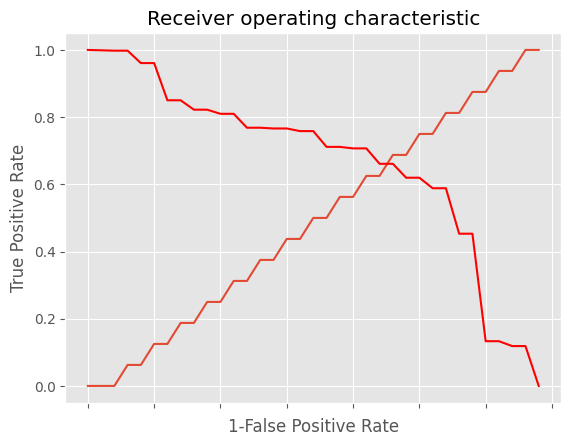

In [ ]:
from sklearn.metrics import roc_curve, auc
import pylab as pl

fpr, tpr, thresholds =roc_curve(Y_test_preop, yp)
roc_auc = auc(fpr, tpr)
print("Area under the ROC curve : %f" % roc_auc)

i = np.arange(len(tpr)) # index for df
roc = pd.DataFrame({'fpr' : pd.Series(fpr, index=i),'tpr' : pd.Series(tpr, index = i), '1-fpr' : pd.Series(1-fpr, index = i), 'tf' : pd.Series(tpr - (1-fpr), index = i), 'thresholds' : pd.Series(thresholds, index = i)})
roc.iloc[(roc.tf-0).abs().argsort()[:1]]

# Plot tpr vs 1-fpr
fig, ax = pl.subplots()
pl.plot(roc['tpr'])
pl.plot(roc['1-fpr'], color = 'red')
pl.xlabel('1-False Positive Rate')
pl.ylabel('True Positive Rate')
pl.title('Receiver operating characteristic')
ax.set_xticklabels([])


In [ ]:
roc

,fpr,tpr,1-fpr,tf,thresholds
0,0.000000,0.0000,1.000000,-1.000000,1.000000e+00
1,0.001119,0.0000,0.998881,-0.998881,1.127494e-62
2,0.002237,0.0000,0.997763,-0.997763,7.391014e-75
3,0.002237,0.0625,0.997763,-0.935263,7.328181e-75
4,0.039150,0.0625,0.960850,-0.898350,7.261723e-93
5,0.039150,0.1250,0.960850,-0.835850,4.055275e-93
6,0.149888,0.1250,0.850112,-0.725112,7.283394e-123
7,0.149888,0.1875,0.850112,-0.662612,6.903857e-123
8,0.177852,0.1875,0.822148,-0.634648,1.541378e-124
9,0.177852,0.2500,0.822148,-0.572148,1.371214e-124


In [ ]:
a = yp> 4.900819e-143

In [ ]:
roc_auc_score(Y_test_preop, a.astype(int))

0.6430369127516778

In [ ]:
a = a.astype(int)

In [ ]:
df_test_preop_preprocessed['Predicted'] = yp

In [ ]:
df_test_preop_preprocessed.to_excel('10_fold_cv_results_preop.xlsx', index = False)

In [ ]:
l = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

In [ ]:
roc_auc_score(Y_test_preop, l)

0.5301314317673378

## Intra-Op




### Read Data

In [ ]:
df_train_intraop = pd.read_csv('/content/drive/MyDrive/ML2 Project/dataset.csv', low_memory = False)
df_test_intraop = pd.read_csv('/content/drive/MyDrive/testing.csv', low_memory = False)


In [ ]:
df_train_intraop = df_train_intraop[df_test_intraop.columns.values.tolist()]
df_train_intraop.replace(r'^\s*$', np.nan, regex=True, inplace = True)
df_test_intraop.replace(r'^\s*$', np.nan, regex=True, inplace = True)



In [ ]:
df_test.columns

Index(['TempSNO', 'gender_id', 'patient_age', 'city_id', 'Ethicity_language',
       'date_of_admission', 'date_of_surgery', 'date_of_discharge',
       'Admission_to_surgery', 'LOS_Surgery_to_discharge',
       ...
       'ventricular_arrythmia', 'inotropics_used', 'atrial_fibrillation',
       'dialysis_newly_required', 'post_operative_stroke', 'sternum_deep',
       'in_hospital_mortality', 'mortality_date', 'or_for_sternal_debridement',
       'specify_other'],
      dtype='object', length=144)

### Pre-process

In [ ]:
df_train_intraop_preprocessed = pre_process(df_train_intraop, type_ = 'train', problem_type = 'intraop')
df_test_intraop_preprocessed = pre_process(df_test_intraop, type_ = 'test', problem_type = 'intraop')

In [ ]:
pd.DataFrame(X_test_intraop_preprocessed.dtypes).to_csv('dtypes.csv')

In [ ]:
print('Cardiac_Presentation_on_Admission')
print('Train: ', sorted(df_train_intraop_preprocessed['Cardiac_Presentation_on_Admission'].unique()))
print('Test:  ', sorted(df_test_intraop_preprocessed['Cardiac_Presentation_on_Admission'].unique()))

print('\nFirstCVSurgery')
print('Train: ', sorted(df_train_intraop_preprocessed['FirstCVSurgery'].unique()))
print('Test:  ', sorted(df_test_intraop_preprocessed['FirstCVSurgery'].unique()))

print('\nGender')
print('Train: ', sorted(df_train_intraop_preprocessed['gender_id'].unique()))
print('Test:  ', sorted(df_test_intraop_preprocessed['gender_id'].unique()))

print('\nCABG_status')
print('Train: ', sorted(df_train_intraop_preprocessed['CABG_status'].unique()))
print('Test:  ', sorted(df_test_intraop_preprocessed['CABG_status'].unique()))

print('\nFirstCVSurgery')
print('Train: ', sorted(df_train_intraop_preprocessed['FirstCVSurgery'].unique()))
print('Test:  ', sorted(df_test_intraop_preprocessed['FirstCVSurgery'].unique()))

print('\nTotal_bypasses_grafted')
print('Train: ', sorted(df_train_intraop_preprocessed['Total_bypasses_grafted'].unique()))
print('Test:  ', sorted(df_test_intraop_preprocessed['Total_bypasses_grafted'].unique()))

Cardiac_Presentation_on_Admission
Train:  [0, 1, 2, 3, 4, 5]
Test:   [0, 1, 2, 3, 4, 5]

FirstCVSurgery
Train:  [0, 1, 2, 3]
Test:   [0, 1]

Gender
Train:  [0, 1]
Test:   [0, 1]

CABG_status
Train:  [0, 1, 2, 3]
Test:   [0, 1, 2, 3]

FirstCVSurgery
Train:  [0, 1, 2, 3]
Test:   [0, 1]

Total_bypasses_grafted
Train:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test:   [0, 1, 2, 3, 4, 5, 6, 8]


### Scaling

In [ ]:
# feat_to_scale = ['patient_age', 'BMI', 'last_hematocrit', 'last_cretenine_preop', 'BPsystolic', 'ejection_fraction']

# maxes_ = df_train_preop_preprocessed[feat_to_scale].max().to_dict()
# mins_ = df_train_preop_preprocessed[feat_to_scale].min().to_dict()

# df_train_preop_preprocessed_scaled = df_train_preop_preprocessed.copy()
# df_test_preop_preprocessed_scaled = df_test_preop_preprocessed.copy()

# df_train_preop_preprocessed_scaled[feat_to_scale] = act_minmax_scale(df_train_preop_preprocessed, feat_to_scale, maxes_, mins_)
# df_test_preop_preprocessed_scaled[feat_to_scale] = act_minmax_scale(df_test_preop_preprocessed, feat_to_scale, maxes_, mins_)

###Seperating target variable from the training data

In [ ]:
X_train_intraop_preprocessed = df_train_intraop_preprocessed.copy()
print(df_train_intraop_preprocessed.shape)
Y_train_intraop = X_train_intraop_preprocessed.pop('in_hospital_mortality')
print(X_train_intraop_preprocessed.shape)

(5363, 117)
(5363, 116)


###Single training cycle (XGB)

In [ ]:
from xgboost import XGBClassifier
bst = XGBClassifier(n_estimators = 10000, max_depth = 0, scale_pos_weight = 50, objective = 'binary:logistic', eval_metric = ['auc', 'error', 'logloss'], enable_categorical=True, device="cuda", subsample = 0.5)

In [ ]:
bst.fit(X_train_intraop_preprocessed, Y_train_intraop)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [05:23:47] WARNING: /workspace/src/context.cc:44: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric=['auc', 'error', 'logloss'],
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=0,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None,
              n_estimators=10000, n_jobs=None, num_parallel_tree=None,
              random_state=None, ...)

###Single testing cycle (XGB)

In [ ]:
yp

array([[9.9998e-01, 2.2080e-05],
       [9.9841e-01, 1.5916e-03],
       [1.0000e+00, 1.7367e-06],
       ...,
       [1.0000e+00, 4.3955e-07],
       [1.0000e+00, 1.2955e-06],
       [1.0000e+00, 3.2200e-06]], dtype=float32)

In [ ]:
X_test_intraop_preprocessed = df_test_intraop_preprocessed.copy()
Y_test_intraop = X_test_intraop_preprocessed.pop('in_hospital_mortality')

yp = bst.predict(X_test_intraop_preprocessed)
# ROC
print(roc_auc_score(Y_test_intraop.values.tolist(), yp))
print(precision_score(Y_test_intraop.values.tolist(), yp))
print(recall_score(Y_test_intraop.values.tolist(), yp))
print(f1_score(Y_test_intraop.values.tolist(), yp))
print()

0.9358221476510067
0.8235294117647058
0.875
0.8484848484848485



In [ ]:
print(classification_report(Y_test_intraop, yp))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       894
           1       0.82      0.88      0.85        16

    accuracy                           0.99       910
   macro avg       0.91      0.94      0.92       910
weighted avg       0.99      0.99      0.99       910



In [ ]:
df_test_intraop_preprocessed['Predicted'] = yp

In [ ]:
df_test_intraop_preprocessed.to_csv('single_cycle_xgb_intraop.csv', index = False)

###Multiple Training & Testing Cycles

####K-Fold Stratified Cross-Validation

In [ ]:
# Oversampling
oversample = SMOTE()
X_train_preop_preprocessed_scaled_oversampled, Y_train_preop_oversampled = oversample.fit_resample(X_train_preop_preprocessed_scaled, Y_train_preop)

# Make df with intercept column
X_train_preop_preprocessed_scaled_oversampled_with_intercept = intercept_df(X_train_preop_preprocessed_scaled_oversampled)

# Combining back the over-sampled training and testing sets
df_train_preop_preprocessed_scaled_oversampled_with_intercept = X_train_preop_preprocessed_scaled_oversampled_with_intercept.copy()
df_train_preop_preprocessed_scaled_oversampled_with_intercept['in_hospital_mortality'] = Y_train_preop_oversampled

# Resample the dataframe based on target variable





In [ ]:
# Resfuffling the dataframe such that the target variable contains alternate values
target_zero_index_list = df_train_preop_preprocessed_scaled_oversampled_with_intercept[df_train_preop_preprocessed_scaled_oversampled_with_intercept['in_hospital_mortality'] == 0].index.values.tolist()
target_one_index_list = df_train_preop_preprocessed_scaled_oversampled_with_intercept[df_train_preop_preprocessed_scaled_oversampled_with_intercept['in_hospital_mortality'] == 1].index.values.tolist()

alternate_list = []
count = 0
for i in range(0,len(target_zero_index_list)):
  alternate_list.insert(count, target_zero_index_list[i])
  alternate_list.insert(count+1, target_one_index_list[i])
  count = count+2

df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled = df_train_preop_preprocessed_scaled_oversampled_with_intercept.loc[df_train_preop_preprocessed_scaled_oversampled_with_intercept.index[alternate_list]]


In [ ]:
# Creating k folds of r_train:r_test ratio
k = 10
n = df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled.shape[0]
n_test = n/k
n_test = int(n_test)
n_train = n-n_test

training_folds = {}
testing_folds = {}
from_samples = 0
to_samples = n_test
for i in range(k):
  testing_folds[i] = df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled.iloc[from_samples:to_samples,]
  training_folds[i] = df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled.loc[~df_train_preop_preprocessed_scaled_oversampled_with_intercept_shuffled.index.isin(testing_folds[i].index.values.tolist())]
  from_samples = to_samples
  to_samples = to_samples + n_test

In [ ]:
betas_fold = {}
accuracy_folds = {}
for i in trange(k):
  training_data = training_folds[i]
  testing_data = testing_folds[i]
  training_data = training_data.sample(frac = 1)
  testing_data = testing_data.sample(frac = 1)
  y_train = training_data.pop('in_hospital_mortality')
  y_test = testing_data.pop('in_hospital_mortality')

  (intercept, beta, bse, fitll) = fit_firth(y_train, training_data)
  b = beta
  betas = [intercept] + beta
  betas_fold[i] = betas

  yp = get_predictions(testing_data, betas)
  # ROC
  accuracy_folds[i] = roc_auc_score(y_test, yp)
  print('fold: ', i)
  print('accruacy: ', roc_auc_score(y_test, yp))




  0%|          | 0/10 [00:00<?, ?it/s]

<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(b

fold:  10
accruacy:  0.8409541420118343


<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(b

fold:  10
accruacy:  0.9556323964497041


...

<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(b

fold:  10
accruacy:  0.9272559171597633


<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(b

fold:  10
accruacy:  0.9195229289940828


<ipython-input-142-800241ceafab>:2: RuntimeWarning: divide by zero encountered in log
  return -(logit.loglike(beta) + 0.5*np.log(np.linalg.det(-logit.hessian(beta))))
<ipython-input-142-800241ceafab>:51: RuntimeWarning: invalid value encountered in sqrt
  bse = np.sqrt(np.diagonal(np.linalg.pinv(-logit_model.hessian(beta_iterations[-1]))))


In [ ]:
betas_df_10_fold = pd.DataFrame(betas_fold)
betas_df_10_fold['Var'] = training_data.columns.values.tolist()
betas_df_10_fold.to_excel('betas_10_fold_cv.xlsx', index = False)

In [ ]:
import json
with open('betas.json', 'w') as fp:
  json.dump(betas_fold, fp)

In [ ]:
betas_df_10_fold = pd.read_excel('betas_10_fold_cv.xlsx')

/usr/local/lib/python3.10/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Sparkline Group extension is not supported and will be removed
  warn(msg)


In [ ]:
betas_df_10_fold = betas_df_10_fold.set_index(['Var'])

In [ ]:
betas = betas_df_10_fold.mean(axis = 1).values.tolist()

In [ ]:
X_test_preop_preprocessed_scaled = df_test_preop_preprocessed_scaled.copy()
Y_test_preop = X_test_preop_preprocessed_scaled.pop('in_hospital_mortality')
X_test_preop_preprocessed_scaled_with_intercept = intercept_df(X_test_preop_preprocessed_scaled)


In [ ]:
yp = get_predictions(X_test_preop_preprocessed_scaled_with_intercept, betas)
# ROC
print('accruacy: ', roc_auc_score(Y_test_preop, yp))

accruacy:  0.6703719239373602


Area under the ROC curve : 0.670372


[Text(-5.0, 0, ''),
 Text(0.0, 0, ''),
 Text(5.0, 0, ''),
 Text(10.0, 0, ''),
 Text(15.0, 0, ''),
 Text(20.0, 0, ''),
 Text(25.0, 0, ''),
 Text(30.0, 0, ''),
 Text(35.0, 0, ''),
 Text(40.0, 0, '')]

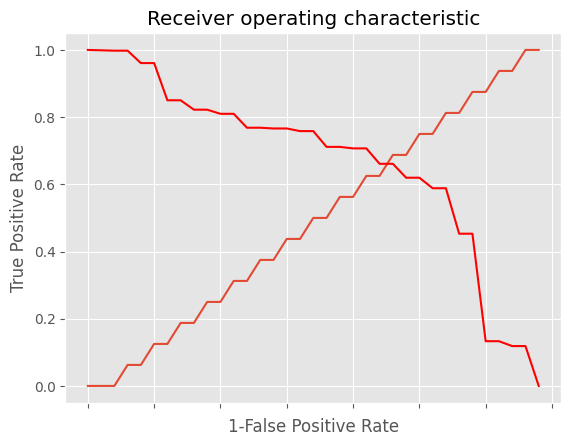

In [ ]:
from sklearn.metrics import roc_curve, auc
import pylab as pl

fpr, tpr, thresholds =roc_curve(Y_test_preop, yp)
roc_auc = auc(fpr, tpr)
print("Area under the ROC curve : %f" % roc_auc)

i = np.arange(len(tpr)) # index for df
roc = pd.DataFrame({'fpr' : pd.Series(fpr, index=i),'tpr' : pd.Series(tpr, index = i), '1-fpr' : pd.Series(1-fpr, index = i), 'tf' : pd.Series(tpr - (1-fpr), index = i), 'thresholds' : pd.Series(thresholds, index = i)})
roc.iloc[(roc.tf-0).abs().argsort()[:1]]

# Plot tpr vs 1-fpr
fig, ax = pl.subplots()
pl.plot(roc['tpr'])
pl.plot(roc['1-fpr'], color = 'red')
pl.xlabel('1-False Positive Rate')
pl.ylabel('True Positive Rate')
pl.title('Receiver operating characteristic')
ax.set_xticklabels([])


In [ ]:
roc

,fpr,tpr,1-fpr,tf,thresholds
0,0.000000,0.0000,1.000000,-1.000000,1.000000e+00
1,0.001119,0.0000,0.998881,-0.998881,1.127494e-62
2,0.002237,0.0000,0.997763,-0.997763,7.391014e-75
3,0.002237,0.0625,0.997763,-0.935263,7.328181e-75
4,0.039150,0.0625,0.960850,-0.898350,7.261723e-93
5,0.039150,0.1250,0.960850,-0.835850,4.055275e-93
6,0.149888,0.1250,0.850112,-0.725112,7.283394e-123
7,0.149888,0.1875,0.850112,-0.662612,6.903857e-123
8,0.177852,0.1875,0.822148,-0.634648,1.541378e-124
9,0.177852,0.2500,0.822148,-0.572148,1.371214e-124


In [ ]:
a = yp> 4.900819e-143

In [ ]:
roc_auc_score(Y_test_preop, a.astype(int))

0.6430369127516778

In [ ]:
a = a.astype(int)

In [ ]:
df_test_preop_preprocessed['Predicted'] = yp

In [ ]:
df_test_preop_preprocessed.to_excel('10_fold_cv_results_preop.xlsx', index = False)

In [ ]:
l = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

In [ ]:
roc_auc_score(Y_test_preop, l)

0.5301314317673378